In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier  
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
import streamlit as st


<h3 style="color:black;">
Xử Lý Dữ Liệu
</h3>


In [2]:

file_path = "Databds_CT1.csv"

try:
    df = pd.read_csv(file_path)
    print("✅ File CSV đã được đọc thành công. Dữ liệu đầu tiên:")
    print(df.head().to_markdown(index=False))
except FileNotFoundError:
    print(f"❌ Lỗi: Không tìm thấy file '{file_path}'.")
    df = pd.DataFrame()  # tạo DataFrame rỗng để tránh lỗi tiếp theo
except Exception as e:
    print(f"❌ Lỗi khi đọc file: {e}")
    df = pd.DataFrame()

# ===============================
# Kiểm tra df có dữ liệu không
# ===============================
if df.empty:
    print("❌ DataFrame rỗng. Không thể tiếp tục xử lý dữ liệu.")
else:
    #  Điền khuyết và chuẩn hóa cột địa lý 
    for col, default in [('ward', 'Chưa rõ Phường'),
                         ('district', 'Chưa rõ Quận/Huyện'),
                         ('province', 'Unknown')]:
        if col in df.columns:
            df[col] = df[col].fillna(default)
            df[col] = df[col].astype(str).str.strip().str.title()

    #  Chuẩn hóa 'property_type' 
    if 'property_type' in df.columns:
        df['property_type'] = df['property_type'].astype(str).str.strip().str.title()

    #  Điền khuyết và tạo cột is_company 
    if 'company_post' in df.columns:
        df['company_post'] = df['company_post'].fillna('Personal/Unknown')
        df['company_post'] = df['company_post'].astype(str).str.strip()
        df['is_company'] = df['company_post'].apply(lambda x: 0 if x in ['Personal/Unknown','Individual/Unknown'] else 1)

    #  4. Xử lý cột 'title' 
    if 'title' in df.columns:
        df['title'] = df['title'].fillna('')
        df['title_length'] = df['title'].apply(len)
        df['is_hot_listing'] = df['title'].str.contains('HOT|Giá Tốt|Cần Bán Gấp', case=False, na=False).astype(int)

    #  5. Xử lý cột 'description' 
    if 'description' in df.columns:
        df['description'] = df['description'].fillna('')
        df['content_length'] = df['description'].apply(len)
        df['has_legal_documents'] = df['description'].str.contains('sổ hồng|sổ đỏ|pháp lý rõ ràng', case=False, na=False).astype(int)

    #  6. TF-IDF cho 'title' 
    if 'title' in df.columns:
        tfidf_title = TfidfVectorizer(max_features=500)
        X_title = tfidf_title.fit_transform(df['title'])
        df_title_tfidf = pd.DataFrame(X_title.toarray(), columns=tfidf_title.get_feature_names_out())
        df = pd.concat([df.reset_index(drop=True), df_title_tfidf.reset_index(drop=True)], axis=1)
        df.drop('title', axis=1, inplace=True)

    #  7. TF-IDF cho 'description' 
    if 'description' in df.columns:
        tfidf_desc = TfidfVectorizer(max_features=1000)
        X_desc = tfidf_desc.fit_transform(df['description'])
        df_desc_tfidf = pd.DataFrame(X_desc.toarray(), columns=tfidf_desc.get_feature_names_out())
        df = pd.concat([df.reset_index(drop=True), df_desc_tfidf.reset_index(drop=True)], axis=1)
        df.drop('description', axis=1, inplace=True)

    #  8. Chuyển bool/int sang float 
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
    df[bool_cols] = df[bool_cols].astype(float)

    int_cols = df.select_dtypes(include=['int64', 'int32']).columns.tolist()
    df[int_cols] = df[int_cols].astype(float)

    #  9. Fillna cho object còn lại 
    object_cols = df.select_dtypes(include=['object']).columns.tolist()
    df[object_cols] = df[object_cols].fillna('')

    #  10. Chuẩn hóa tên cột 
    df.columns = [col.strip().lower() for col in df.columns]

    #  11. Xử lý thời gian từ actual_date 
    if 'actual_date' in df.columns:
        df['actual_date'] = pd.to_datetime(df['actual_date'], errors='coerce')
        df['actual_year'] = df['actual_date'].dt.year
        df['actual_month'] = df['actual_date'].dt.month
        df['actual_weekday'] = df['actual_date'].dt.dayofweek
        df.drop('actual_date', axis=1, inplace=True)

    #  12. Tạo tần suất district/ward 
    if 'district' in df.columns:
        district_counts = df['district'].value_counts(normalize=True)
        df['district_frequency'] = df['district'].map(district_counts)

    if 'ward' in df.columns:
        ward_counts = df['ward'].value_counts(normalize=True)
        df['ward_frequency'] = df['ward'].map(ward_counts)

    #  13. One-Hot Encoding cho property_type 
    if 'property_type' in df.columns:
        df_property_encoded = pd.get_dummies(df['property_type'], prefix='property_type')
        df = pd.concat([df, df_property_encoded], axis=1)
        df.drop('property_type', axis=1, inplace=True)

    print("✅ Pipeline xử lý dữ liệu hoàn tất. Dữ liệu hiện tại:")
    print(df.head(1).to_markdown(index=False))


✅ File CSV đã được đọc thành công. Dữ liệu đầu tiên:
|      price |   price_per_m2_million | actual_date             |     list_time | province       | district          | ward                               |   longitude |   latitude | property_type   |   apartment_type | project_name          |   area |   num_rooms |   num_toilets | company_post   |   contain_videos | is_pinned   |   num_images |   rating_score |   sold_status | title                                                                 | description                                                                          |
|-----------:|-----------------------:|:------------------------|--------------:|:---------------|:------------------|:-----------------------------------|------------:|-----------:|:----------------|-----------------:|:----------------------|-------:|------------:|--------------:|:---------------|-----------------:|:------------|-------------:|---------------:|--------------:|:--------------------------

In [3]:
object_cols = df.select_dtypes(include=['object']).columns.tolist()

if len(object_cols) == 0:
    print("✅ Không còn cột object nào trong df.")
else:
    print("Vẫn còn các cột object:", object_cols)

Vẫn còn các cột object: ['province', 'district', 'ward', 'project_name', 'company_post']


In [4]:
 
import re
def clean_column_names(df):
    new_cols = []
    for col in df.columns:
        col_new = re.sub(r'[^a-z0-9_]+', '_', col.lower()).strip('_')
        new_cols.append(col_new)
    df.columns = new_cols
    return df

df = clean_column_names(df)


<h3 style="color:black;">
Lựa chọn đặc trưng và làm sạch dữ liệu
</h3>


In [8]:
# Các cột cần giữ lại
columns_to_keep = [
    'price', 'price_per_m2_million', 'list_time', 'longitude', 'latitude', 'area',
    'num_rooms', 'num_toilets', 'contain_videos', 'is_pinned', 'num_images',
    'rating_score', 'sold_status', 'title_length', 'content_length', 'posting_year',
    'posting_month', 'posting_weekday', 'district_frequency', 'ward_frequency',
    'project_frequency', 'district'
]

# Chỉ giữ lại các cột có tồn tại trong DataFrame
columns_existing = [c for c in columns_to_keep if c in df.columns]

# Tạo df_valid để kiểm tra dữ liệu thô
df_valid = df[columns_existing].copy()

print("Các cột được giữ:", columns_existing)

# Các cột dùng cho mô hình outlier detection
model_cols = [
    'price', 'price_per_m2_million', 'area',
    'num_rooms', 'num_toilets', 'num_images',
    'rating_score', 'title_length', 'content_length',
    'district_frequency', 'ward_frequency', 'project_frequency'
]
cols_price = [
    'price', 'price_per_m2_million', 'area', 'num_rooms', 'num_toilets',
    'num_images', 'rating_score', 'contain_videos', 'is_pinned',
    'title_length', 'content_length', 'district_frequency', 'ward_frequency'
]
# Lọc theo các cột mô hình (và chỉ lấy những cột đang tồn tại)
model_cols_existing = [c for c in model_cols if c in df.columns]

df_model = df[model_cols_existing].copy()

# Thay NaN bằng 0
df_model = df_model.fillna(0)
df_price = df[cols_price].copy()
df_price = df_price.fillna(0)
print("Các cột mô hình:", model_cols_existing)


Các cột được giữ: ['price', 'price_per_m2_million', 'list_time', 'longitude', 'latitude', 'area', 'num_rooms', 'num_toilets', 'contain_videos', 'is_pinned', 'num_images', 'rating_score', 'sold_status', 'title_length', 'content_length', 'district_frequency', 'ward_frequency', 'district']
Các cột mô hình: ['price', 'price_per_m2_million', 'area', 'num_rooms', 'num_toilets', 'num_images', 'rating_score', 'title_length', 'content_length', 'district_frequency', 'ward_frequency']


In [9]:
features = [
    'price_per_m2_million',
    'longitude',
    'latitude',
    'district_frequency',
    'ward_frequency',
    'actual_year',
    'actual_month'
]

target = 'price'

df_model = df[features + [target]].dropna()


In [11]:
if "district" in df.columns and "price" in df.columns:
    district_price_mean = df.groupby("district")["price"].mean()
    df_valid["price_by_district"] = df["district"].map(district_price_mean)

if "district" in df.columns and "price_per_m2_million" in df.columns:
    district_price_m2_mean = df.groupby("district")["price_per_m2_million"].mean()
    df_valid["price_per_m2_by_district"] = df["district"].map(district_price_m2_mean)

<h3 style="color:black;">
Trực quan hóa dữ liệu (Data Visualization): Biểu đồ cột thể hiện giá bất động sản trung bình theo quận (district)
</h3>


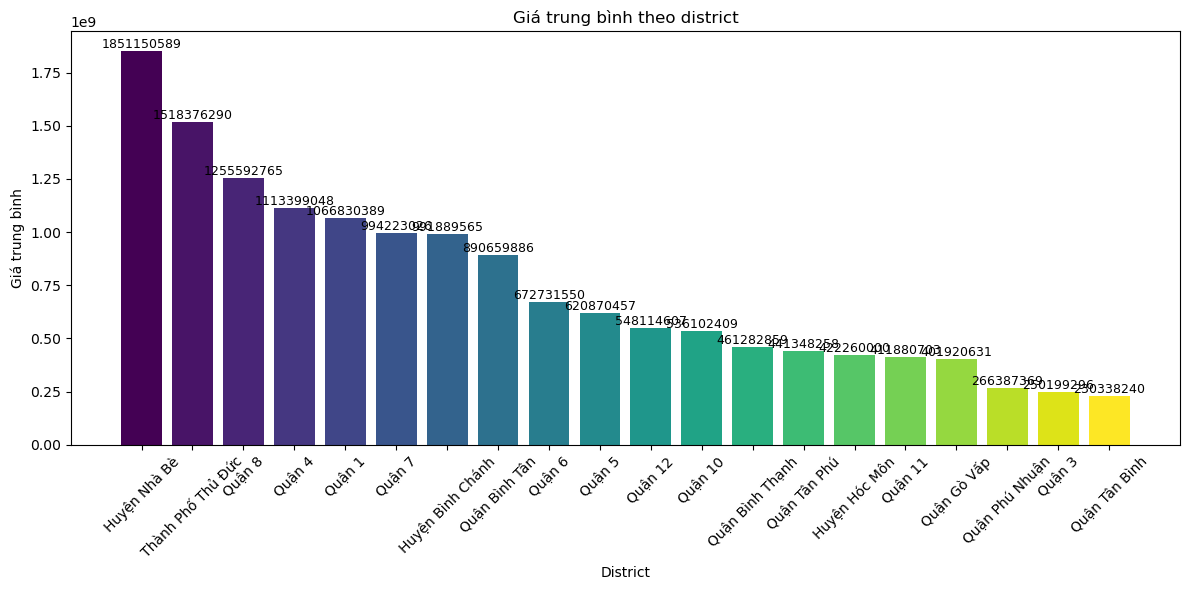

In [12]:
if 'price_by_district' in df_valid.columns:
    district_price = (
        df_valid[['district', 'price_by_district']]
        .drop_duplicates()
        .sort_values('price_by_district', ascending=False)
    )

    plt.figure(figsize=(12,6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(district_price)))

    bars = plt.bar(district_price['district'], district_price['price_by_district'],
                   color=colors)

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h, 
                 f'{h:.0f}', ha='center', va='bottom', fontsize=9)

    plt.xticks(rotation=45)
    plt.title("Giá trung bình theo district")
    plt.ylabel("Giá trung bình")
    plt.xlabel("District")
    plt.tight_layout()
    plt.show()


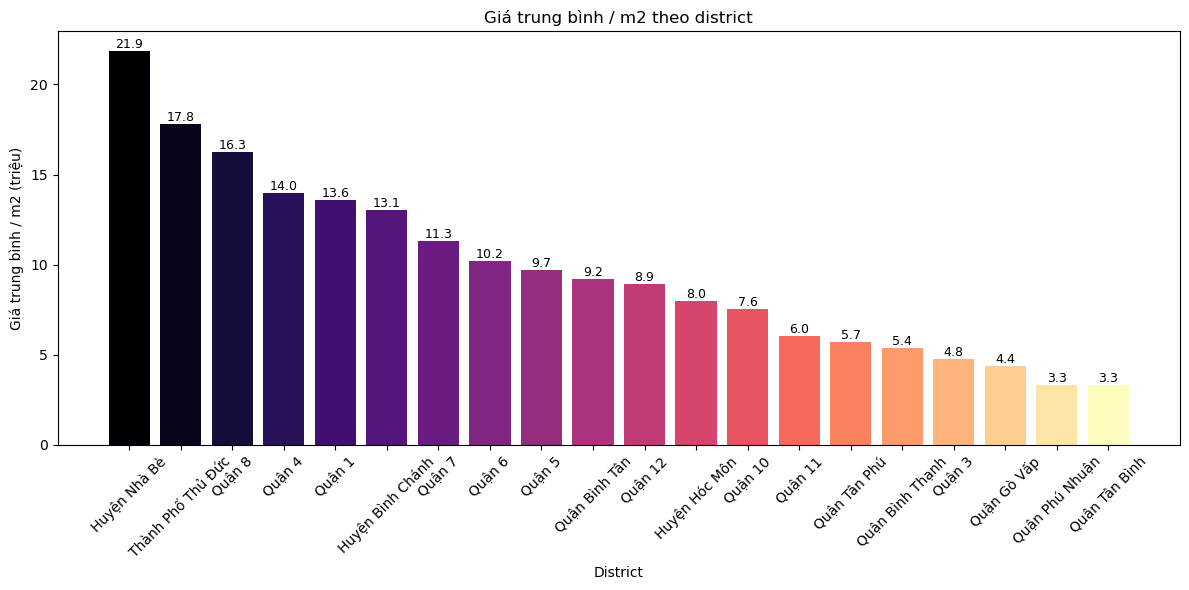

In [13]:
if 'price_per_m2_by_district' in df_valid.columns:
    district_price_m2 = (
        df_valid[['district', 'price_per_m2_by_district']]
        .drop_duplicates()
        .sort_values('price_per_m2_by_district', ascending=False)
    )

    plt.figure(figsize=(12,6))
    colors = plt.cm.magma(np.linspace(0, 1, len(district_price_m2)))

    bars = plt.bar(district_price_m2['district'], district_price_m2['price_per_m2_by_district'],
                   color=colors)

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h, 
                 f'{h:.1f}', ha='center', va='bottom', fontsize=9)

    plt.xticks(rotation=45)
    plt.title("Giá trung bình / m2 theo district")
    plt.ylabel("Giá trung bình / m2 (triệu)")
    plt.xlabel("District")
    plt.tight_layout()
    plt.show()

<h3 style="color:black;">
DỰ ĐOÁN GIÁ BẤT ĐỘNG SẢN BẰNG MÔ HÌNH RANDOM FOREST
</h3>


<h4 style="color:black;">
Huấn luyện và kiểm tra dữ liệu
</h4>


In [17]:


from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


<h4 style="color:black;">
Huấn luyện mô hình Random Forest Regression
</h4>


In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(max_depth=15, n_estimators=200, random_state=42)

<h4 style="color:black;">
Đánh giá mô hình hồi quy 
</h4>


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("sai số trung bình:", mae)
print("phạt nặng sai số lớn:", rmse)
print("càng gần 1 càng tốt:", r2)


sai số trung bình: 194934360.0542435
phạt nặng sai số lớn: 1094358664.284683
càng gần 1 càng tốt: 0.7814344296868334


<h4 style="color:black;">
Sai số trong mô hình
</h4>


In [23]:
import numpy as np

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
accuracy = 100 - mape

print(f"MAPE (sai số %): {mape:.2f}%")
print(f"Độ chính xác xấp xỉ: {accuracy:.2f}%")


MAPE (sai số %): 27.82%
Độ chính xác xấp xỉ: 72.18%


<h4 style="color:black;">
Gía thực tế và giá dự đoán trong mô hình
</h4>


In [24]:
df_compare = pd.DataFrame({
    'Giá thực tế': y_test.values,
    'Giá dự đoán': y_pred,
    'Sai số (%)': abs(y_test.values - y_pred) / y_test.values * 100
})

df_compare.head(10)


,Giá thực tế,Giá dự đoán,Sai số (%)
0,7.500000e+06,8.754358e+06,16.724769
1,1.000000e+07,7.023972e+06,29.760275
2,3.000000e+09,2.796013e+09,6.799559
3,5.000000e+06,6.960326e+06,39.206515
4,4.800000e+06,7.150819e+06,48.975401
5,6.700000e+06,6.810859e+06,1.654610
6,9.000000e+06,7.782105e+06,13.532172
7,5.700000e+06,6.356880e+06,11.524209
8,8.000000e+06,7.102475e+06,11.219064
9,5.700000e+06,7.681363e+06,34.760762


<h3 style="color:black;">
VẼ MÔ HÌNH RANDOM FOREST
</h3>


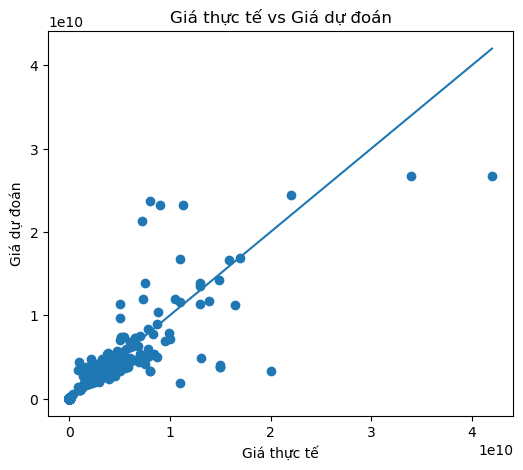

In [26]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("Giá thực tế vs Giá dự đoán")
plt.show()


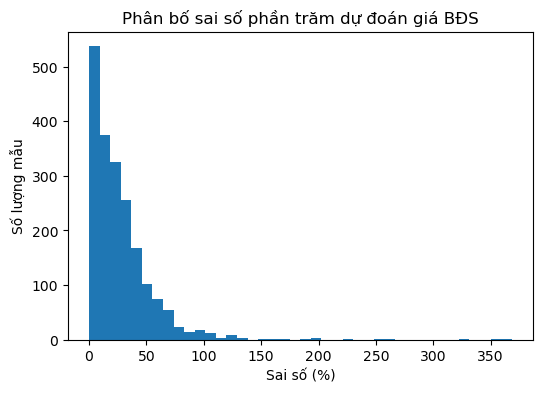

In [27]:
error_percent = np.abs((y_test - y_pred) / y_test) * 100

plt.figure(figsize=(6,4))
plt.hist(error_percent, bins=40)
plt.xlabel("Sai số (%)")
plt.ylabel("Số lượng mẫu")
plt.title("Phân bố sai số phần trăm dự đoán giá BĐS")
plt.show()


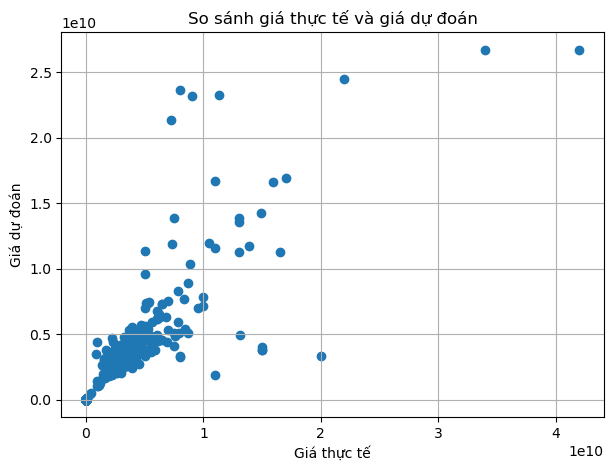

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("So sánh giá thực tế và giá dự đoán")
plt.grid(True)
plt.show()


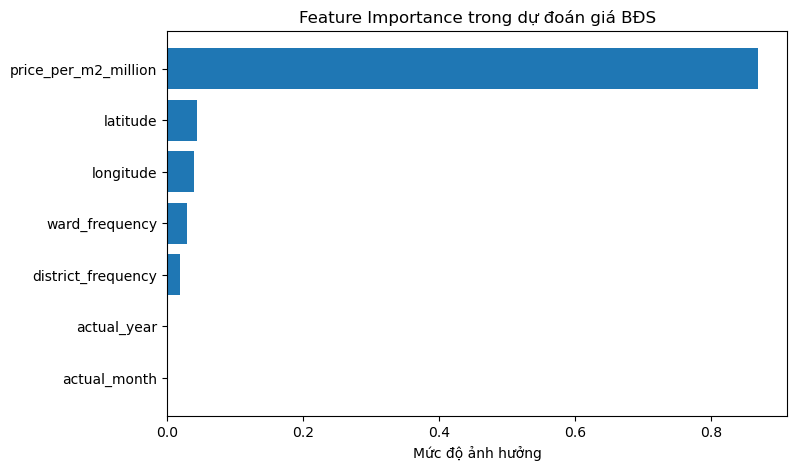

In [29]:
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.xlabel("Mức độ ảnh hưởng")
plt.title("Feature Importance trong dự đoán giá BĐS")
plt.gca().invert_yaxis()
plt.show()


<h3 style="color:black;">
Mô hình đưa ra giá dữ đoán</h3>


In [31]:
sample = pd.DataFrame([{
    'price_per_m2_million': 85,
    'longitude': 106.7,
    'latitude': 10.78,
    'district_frequency': 1200,
    'ward_frequency': 350,
    'actual_year': 2024,
    'actual_month': 12
}])

pred_price = model.predict(sample)
print("Giá dự đoán:", int(pred_price[0]))


Giá dự đoán: 6591213869


<h3 style="color:black;">
Chuẩn bị dữ liệu cho bài toán phân loại (Classification Data Preparation)</h3>


In [35]:
df_valid = df_valid.dropna(subset=['sold_status'])

X = df_valid.drop('sold_status', axis=1)
y = df_valid['sold_status'].astype(int)


<h3 style="color:black;">
Ma trận tương quan</h3>


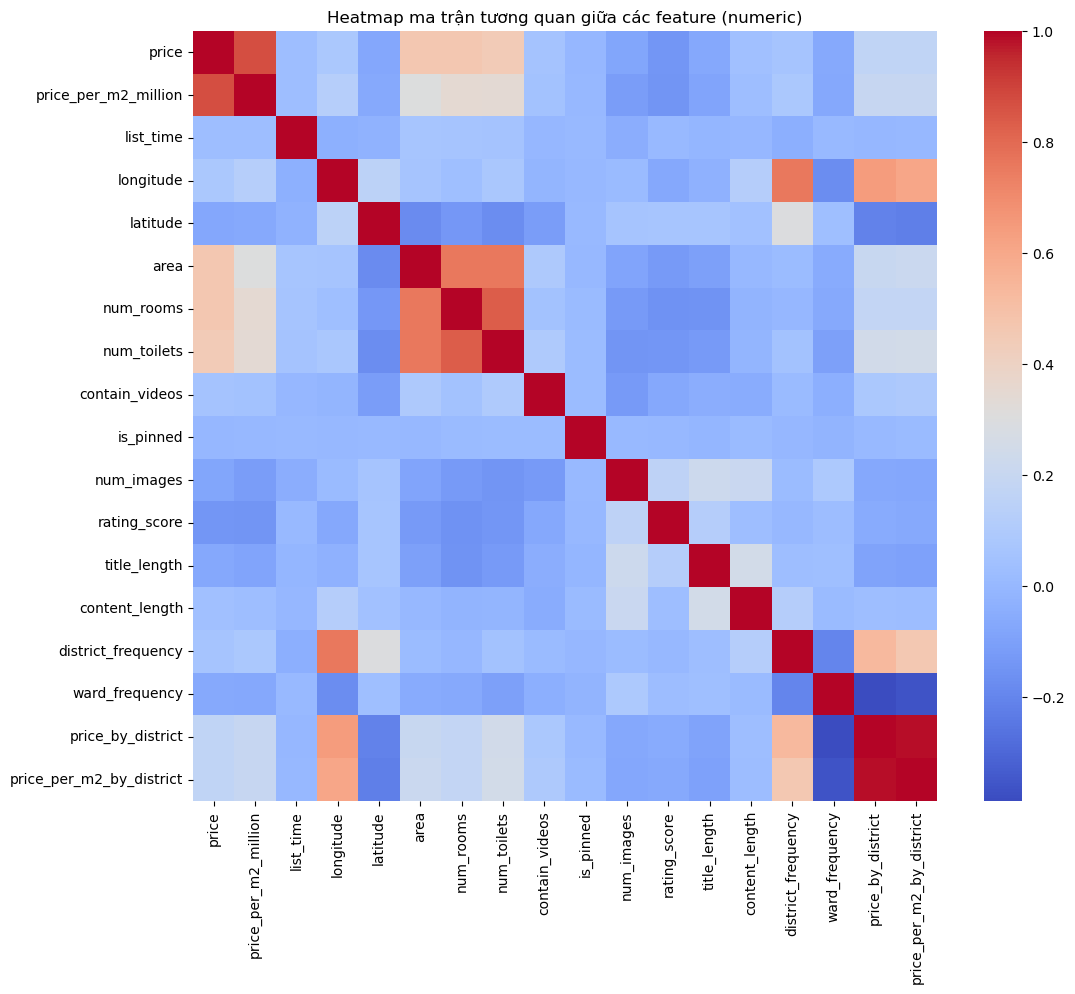

In [38]:
X_num = X.select_dtypes(include=['int', 'float'])
plt.figure(figsize=(12,10))
corr = X_num.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Heatmap ma trận tương quan giữa các feature (numeric)")
plt.show()


<h3 style="color:black;">
Chuẩn hóa dữ liệu</h3>


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df_model)

<h3 style="color:black;">
Mô hình Isolation Forest</h3>


In [41]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    contamination=0.03,       
    random_state=42
)

df['outlier_score'] = iso.fit_predict(X)
df['anomaly'] = df['outlier_score'].apply(lambda x: 'Outlier' if x == -1 else 'Normal')


In [42]:
df['anomaly'].value_counts()


anomaly
Normal     9652
Outlier     299
Name: count, dtype: int64

<h3 style="color:black;">
Trích xuất dữ liệu bất thường</h3>


In [43]:
df_out = df[df['anomaly'] == 'Outlier']
df_out.head(20)


,price,price_per_m2_million,list_time,province,district,ward,longitude,latitude,apartment_type,project_name,...,,,actual_year,actual_month,actual_weekday,district_frequency,ward_frequency,property_type_c_n_h_chung_c,outlier_score,anomaly
25,5.900000e+09,86.764710,1.758035e+12,Tp Hồ Chí Minh,Thành Phố Thủ Đức,Phường An Phú (Quận 2 Cũ),106.753270,10.791790,1.0,Căn hộ D’Lusso,...,0.0,0.0,2025,9,1,0.171641,0.026530,True,-1,Outlier
144,9.000000e+09,120.000000,1.758032e+12,Tp Hồ Chí Minh,Thành Phố Thủ Đức,Phường An Phú (Quận 2 Cũ),106.745960,10.802470,1.0,Lumière Riverside,...,0.0,0.0,2025,9,1,0.171641,0.026530,True,-1,Outlier
170,1.050000e+10,122.093025,1.758032e+12,Tp Hồ Chí Minh,Quận 10,Phường 12,106.678890,10.776200,1.0,Hà Đô Centrosa Garden,...,0.0,0.0,2025,9,1,0.046729,0.035775,True,-1,Outlier
192,1.500000e+10,113.636360,1.758031e+12,Tp Hồ Chí Minh,Quận Gò Vấp,Phường 16,106.664734,10.842343,2.0,,...,0.0,0.0,2025,9,1,0.057180,0.008843,True,-1,Outlier
211,3.256000e+09,46.514286,1.758031e+12,Tp Hồ Chí Minh,Thành Phố Thủ Đức,Phường Linh Xuân (Quận Thủ Đức Cũ),106.773600,10.880408,1.0,,...,0.0,0.0,2025,9,1,0.171641,0.001005,True,-1,Outlier
234,2.080000e+10,94.545456,1.758030e+12,Tp Hồ Chí Minh,Quận Bình Tân,Phường Bình Hưng Hoà B,106.599700,10.818957,2.0,,...,0.0,0.0,2025,9,1,0.037886,0.002010,True,-1,Outlier
265,8.700000e+09,170.588240,1.758029e+12,Tp Hồ Chí Minh,Quận 1,Phường Đa Kao,106.699600,10.788530,1.0,The MarQ,...,0.0,0.0,2025,9,1,0.043915,0.007637,True,-1,Outlier
269,2.690000e+10,192.142850,1.758029e+12,Tp Hồ Chí Minh,Thành Phố Thủ Đức,Phường Thủ Thiêm (Quận 2 Cũ),106.710490,10.770060,3.0,The Metropole Thủ Thiêm,...,0.0,0.0,2025,9,1,0.171641,0.001206,True,-1,Outlier
282,2.350000e+09,33.571430,1.758029e+12,Tp Hồ Chí Minh,Thành Phố Thủ Đức,Phường Bình Chiểu (Quận Thủ Đức Cũ),106.727960,10.883640,1.0,Fresca Riverside,...,0.0,0.0,2025,9,1,0.171641,0.001005,True,-1,Outlier
311,2.350000e+09,33.571430,1.758028e+12,Tp Hồ Chí Minh,Thành Phố Thủ Đức,Phường Bình Chiểu (Quận Thủ Đức Cũ),106.727960,10.883640,1.0,Fresca Riverside,...,0.0,0.0,2025,9,1,0.171641,0.001005,True,-1,Outlier


In [44]:
df['price'] = df['price'].astype('int64')


In [107]:
# Tính các ngưỡng một lần (tối ưu & dễ hiểu)
price_low = df['price'].quantile(0.10)
price_high = df['price'].quantile(0.90)

price_m2_high = df['price_per_m2_million'].quantile(0.90)
area_low = df['area'].quantile(0.10)

content_short = 100
image_few = 2


def reason(row):
    reasons = []

    # Tránh lỗi NaN
    price = row.get('price', None)
    area = row.get('area', None)
    price_m2 = row.get('price_per_m2_million', None)
    content_len = row.get('content_length', None)
    num_images = row.get('num_images', None)

    if price is not None:
        if price < price_low:
            reasons.append("Giá thấp bất thường")
        elif price > price_high:
            reasons.append("Giá cao bất thường")

    if area is not None and price_m2 is not None:
        if area < area_low and price_m2 > price_m2_high:
            reasons.append("Diện tích nhỏ nhưng giá/m² cao")

    if content_len is not None:
        if content_len < content_short:
            reasons.append("Nội dung mô tả quá ngắn")

    if num_images is not None:
        if num_images <= image_few:
            reasons.append("Ít hình ảnh so với mặt bằng")

    return ", ".join(reasons) if reasons else "đang xem xét giá lại"
df_out = df[df['anomaly'] == 'Outlier'].copy()
df_out['reason'] = df_out.apply(reason, axis=1)

columns_to_show = [
    'price', 'price_per_m2_million', 'area',
    'num_images', 'content_length',
    'district', 'ward', 'project_name', 'reason'
]

df_out[columns_to_show].head(10)

,price,price_per_m2_million,area,num_images,content_length,district,ward,project_name,reason
25,5900000000,86.764710,68.0,8.0,285.0,Thành Phố Thủ Đức,Phường An Phú (Quận 2 Cũ),Căn hộ D’Lusso,Giá cao bất thường
144,9000000000,120.000000,75.0,12.0,553.0,Thành Phố Thủ Đức,Phường An Phú (Quận 2 Cũ),Lumière Riverside,Giá cao bất thường
170,10500000000,122.093025,86.0,5.0,1189.0,Quận 10,Phường 12,Hà Đô Centrosa Garden,Giá cao bất thường
192,15000000000,113.636360,132.0,6.0,854.0,Quận Gò Vấp,Phường 16,,Giá cao bất thường
211,3256000000,46.514286,70.0,8.0,981.0,Thành Phố Thủ Đức,Phường Linh Xuân (Quận Thủ Đức Cũ),,Giá cao bất thường
234,20800000000,94.545456,220.0,8.0,500.0,Quận Bình Tân,Phường Bình Hưng Hoà B,,Giá cao bất thường
265,8700000000,170.588240,51.0,3.0,1005.0,Quận 1,Phường Đa Kao,The MarQ,Giá cao bất thường
269,26900000000,192.142850,140.0,3.0,1527.0,Thành Phố Thủ Đức,Phường Thủ Thiêm (Quận 2 Cũ),The Metropole Thủ Thiêm,Giá cao bất thường
282,2350000000,33.571430,70.0,5.0,471.0,Thành Phố Thủ Đức,Phường Bình Chiểu (Quận Thủ Đức Cũ),Fresca Riverside,đang xem xét giá lại
311,2350000000,33.571430,70.0,5.0,674.0,Thành Phố Thủ Đức,Phường Bình Chiểu (Quận Thủ Đức Cũ),Fresca Riverside,đang xem xét giá lại


<h3 style="color:black;">
Bản đồ ánh xạ khu vực</h3>


In [108]:
district_map = {
    "Quận 1": {
        "Phường Đa Kao": ["The MarQ"],
        "Phường Bến Nghé": ["Grand Marina Saigon"],
        "Phường Cô Giang": ["Central Garden"],
        "Phường Nguyễn Cư Trinh": ["Cao Ốc BMC"]
    },
    "Thành Phố Thủ Đức": {
        "Phường An Phú (Quận 2 Cũ)": ["D'Lusso", "Masteri An Phú"],
        "Phường Thảo Điền (Quận 2 Cũ)": ["Masteri Thảo Điền"]
    },
    "Quận Bình Thạnh": {
        "Phường 13": ["Vinhomes Central Park"]
    },
    "Quận 10": {
        "Phường 12": ["Hà Đô Centrosa Garden"]
    },
    "Quận 6": {
        "Phường 11": ["An Phú Apartment"]
    }
}


In [109]:
def fill_missing_location(row):
    district = row.get('district')

    if district in district_map:
        wards = list(district_map[district].keys())

        # FIX WARD
        if pd.isna(row['ward']) or row['ward'] not in wards:
            row['ward'] = random.choice(wards)

        # FIX PROJECT
        projects = district_map[district].get(row['ward'], [])
        if pd.isna(row['project_name']) or row['project_name'] in ["", "None"]:
            row['project_name'] = random.choice(projects) if projects else "Chưa xác định"
    else:
        row['ward'] = row['ward'] or "Chưa xác định"
        row['project_name'] = row['project_name'] or "Chưa xác định"

    return row


In [110]:
import random

df_out = df_out.apply(fill_missing_location, axis=1)


In [111]:
columns_to_show = [
    'price', 'area', 'num_images', 'content_length',
    'district', 'ward', 'project_name', 'reason'
]

df_out[columns_to_show].head(20)


,price,area,num_images,content_length,district,ward,project_name,reason
25,5900000000,68.0,8.0,285.0,Thành Phố Thủ Đức,Phường An Phú (Quận 2 Cũ),Căn hộ D’Lusso,Giá cao bất thường
144,9000000000,75.0,12.0,553.0,Thành Phố Thủ Đức,Phường An Phú (Quận 2 Cũ),Lumière Riverside,Giá cao bất thường
170,10500000000,86.0,5.0,1189.0,Quận 10,Phường 12,Hà Đô Centrosa Garden,Giá cao bất thường
192,15000000000,132.0,6.0,854.0,Quận Gò Vấp,Phường 16,Chưa xác định,Giá cao bất thường
211,3256000000,70.0,8.0,981.0,Thành Phố Thủ Đức,Phường An Phú (Quận 2 Cũ),D'Lusso,Giá cao bất thường
234,20800000000,220.0,8.0,500.0,Quận Bình Tân,Phường Bình Hưng Hoà B,Chưa xác định,Giá cao bất thường
265,8700000000,51.0,3.0,1005.0,Quận 1,Phường Đa Kao,The MarQ,Giá cao bất thường
269,26900000000,140.0,3.0,1527.0,Thành Phố Thủ Đức,Phường An Phú (Quận 2 Cũ),The Metropole Thủ Thiêm,Giá cao bất thường
282,2350000000,70.0,5.0,471.0,Thành Phố Thủ Đức,Phường Thảo Điền (Quận 2 Cũ),Fresca Riverside,đang xem xét giá lại
311,2350000000,70.0,5.0,674.0,Thành Phố Thủ Đức,Phường An Phú (Quận 2 Cũ),Fresca Riverside,đang xem xét giá lại


In [79]:
import matplotlib.pyplot as plt

# Gán nhãn mức giá
def price_level(row):
    if row['price'] < price_low:
        return 'Thấp'
    elif row['price'] > price_high:
        return 'Cao'
    else:
        return 'Bình thường'

df_plot = df.copy()
df_plot['price_level'] = df_plot.apply(price_level, axis=1)

plt.figure(figsize=(12,6))
df_plot.boxplot(
    column='price',
    by='district',
    grid=False,
    rot=45
)
plt.title("Phân bố giá theo quận")
plt.suptitle("")
plt.ylabel("Giá")
plt.show()


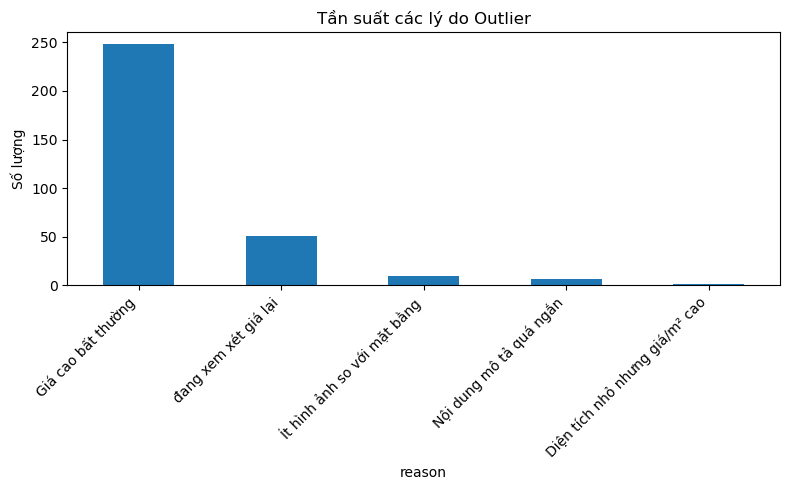

In [81]:
reason_counts = (
    df_out['reason']
    .str.split(", ")
    .explode()
    .value_counts()
)

plt.figure(figsize=(8,5))
reason_counts.plot(kind='bar')

plt.title("Tần suất các lý do Outlier")
plt.ylabel("Số lượng")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<h3 style="color:black;">
Vẽ Mô hình </h3>


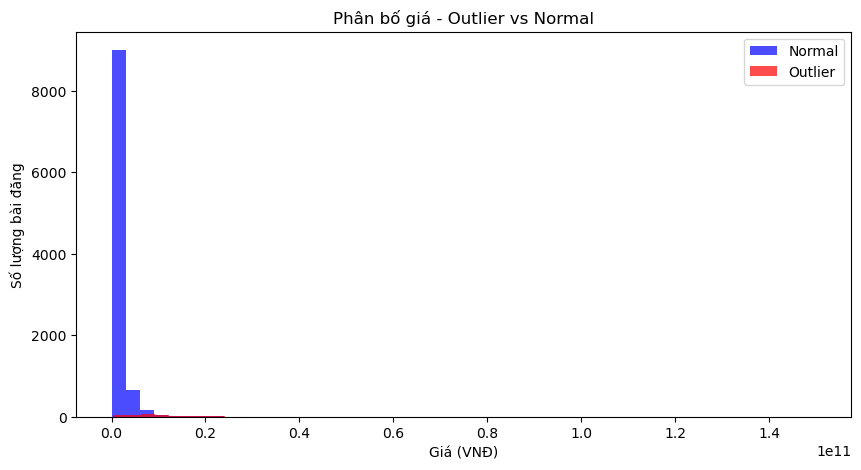

In [73]:
plt.figure(figsize=(10,5))
plt.hist(df['price'], bins=50, alpha=0.7, color='blue', label='Normal')
plt.hist(df_out['price'], bins=50, alpha=0.7, color='red', label='Outlier')
plt.xlabel("Giá (VNĐ)")
plt.ylabel("Số lượng bài đăng")
plt.title("Phân bố giá - Outlier vs Normal")
plt.legend()
plt.show()


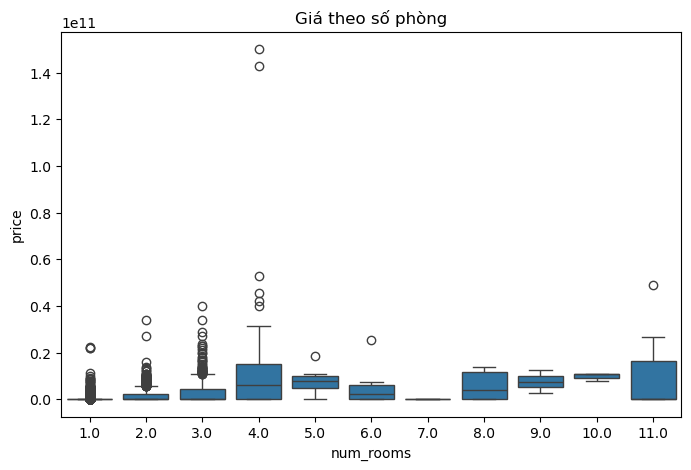

In [74]:
corr_matrix = df_price.corr()
plt.figure(figsize=(8,5))
sns.boxplot(x='num_rooms', y='price', data=df_price)
plt.title("Giá theo số phòng")
plt.show()


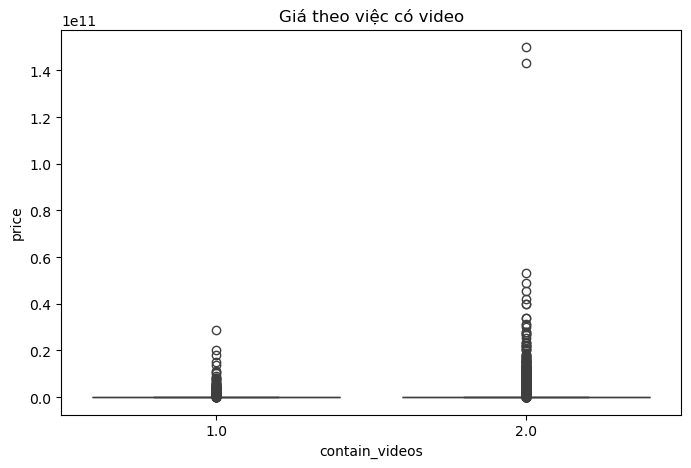

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x='contain_videos', y='price', data=df_price)
plt.title("Giá theo việc có video")
plt.show()


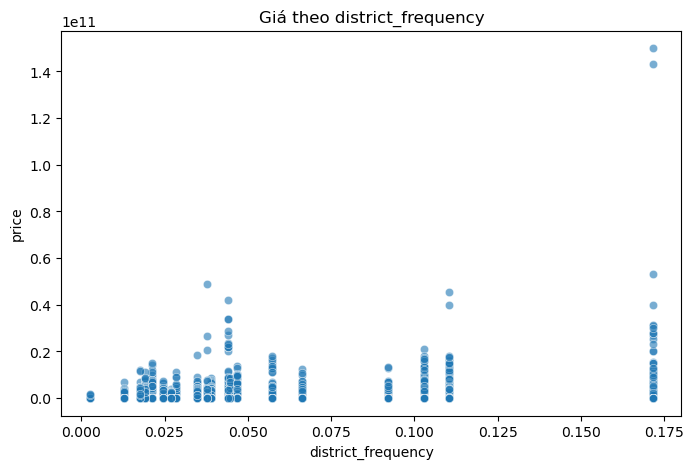

In [83]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='district_frequency', y='price', data=df_price, alpha=0.6)
plt.title("Giá theo district_frequency")
plt.show()


<h3 style="color:black;">
Yếu tố ảnh hưởng đến giá BĐS </h3>


               feature  importance
0                 area    0.268997
10      ward_frequency    0.181748
2          num_toilets    0.144943
8       content_length    0.105052
7         title_length    0.098398
1            num_rooms    0.061081
9   district_frequency    0.060965
3           num_images    0.053211
4         rating_score    0.020015
5       contain_videos    0.005513
6            is_pinned    0.000078


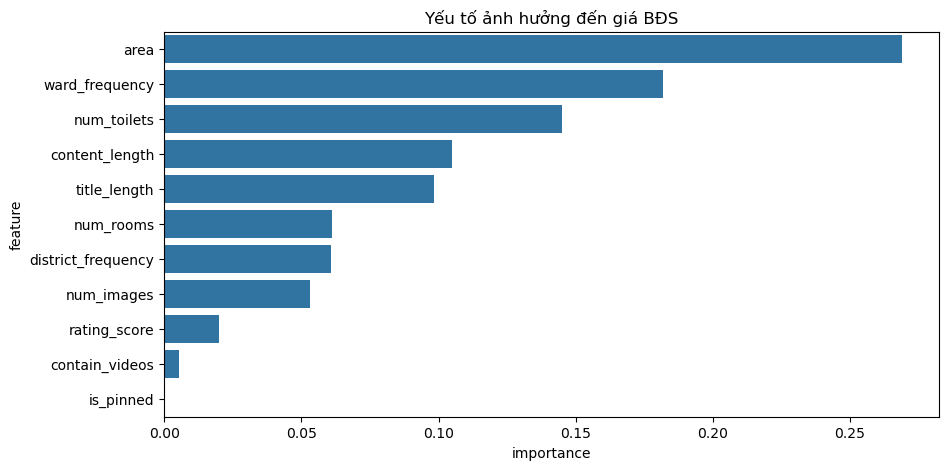

In [84]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder

# X, y
X = df_price.drop(['price','price_per_m2_million'], axis=1)
y = df_price['price']

X['contain_videos'] = X['contain_videos'].astype(int)
X['is_pinned'] = X['is_pinned'].astype(int)

# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)

# Feature importance
feat_imp = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_}).sort_values(by='importance', ascending=False)
print(feat_imp)

plt.figure(figsize=(10,5))
sns.barplot(x='importance', y='feature', data=feat_imp)
plt.title("Yếu tố ảnh hưởng đến giá BĐS")
plt.show()
